## Imports and Sentiment Tools

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

# sentiment tools
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from afinn import Afinn
from pysentimiento import create_analyzer
from transformers import pipeline

In [2]:
files = [f for f in Path('data_filtered/').iterdir() if f.is_file()]
files.reverse()
songs = pd.read_csv(files[0])

for file in files[1:]:
    data = pd.read_csv(file)
    songs = pd.concat([songs, data])

print(len(songs))
songs.head(3)

259458


,Unnamed: 0.1,Unnamed: 0,index,id,name,album_name,artists,danceability,energy,key,...,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres,is_valid_lyrics,valence_norm,lyric_sentiment,alignment_gap
0,0,0,256,3iBgrkexCzVuPy4O9vx7Mf,Glue Song,Glue Song,"[""beabadoobee""]",0.620,0.409,1,...,Pop,81,6764580,80.000000,"[""35l9BRT7MXmM8bv2WDQiyB""]","[""bedroom pop""]",True,0.164,-0.1372,-0.3012
1,1,1,646,60SvhHtwefT0e2G7i7kOH3,New Gold (feat. Tame Impala and Bootie Brown),Cracker Island,"[""Gorillaz"", ""Tame Impala"", ""Bootie Brown""]",0.695,0.923,1,...,Rock,77,24787609,78.333333,"[""3AA28KZvwAUcZuOKwyblJQ"", ""5INjqkS1o8h1imAzPq...","[""indie"", ""neo-psychedelic""]",True,0.102,0.5043,0.4023
2,2,2,891,0FA4wrjDJvJTTU8AepZTup,Watch This - ARIZONATEARS Pluggnb Remix,Watch This (ARIZONATEARS Pluggnb Remix),"[""Lil Uzi Vert"", ""sped up nightcore"", ""ARIZONA...",0.686,0.897,11,...,Hip-Hop,75,19685914,71.333333,"[""4O15NlyKLIASxsJ0PrXPfz"", ""0M2CO5ijP35MDhNwvp...","[""melodic rap"", ""nightcore""]",True,-0.290,-0.9986,-0.7086


In [3]:
songs[['lyric_sentiment', 'alignment_gap']].isna().value_counts()

lyric_sentiment  alignment_gap
False            False            259458
Name: count, dtype: int64

In [3]:
def clean_lyrics(lyrics):
    cleaned = re.sub(r'\[.*?\]', '', lyrics)
    cleaned = re.sub(r'\d{1,2}:\d{2}(\.\d+)?', '', cleaned)
    cleaned = cleaned.strip()
    return cleaned

songs['lyrics'] = songs['lyrics'].apply(clean_lyrics)
songs = songs[songs['is_valid_lyrics'] == True].reset_index(drop=True)
print(f"Tracks entering sentiment pipeline: {len(songs):,}")

Tracks entering sentiment pipeline: 259,458


In [4]:
# creating normalized valence
songs['valence_norm'] = songs['valence'] * 2 - 1
songs[['valence_norm', 'valence']].describe()

,valence_norm,valence
count,259458.000000,259458.000000
mean,-0.123409,0.438296
std,0.483803,0.241901
min,-1.000000,0.000000
25%,-0.522000,0.239000
50%,-0.174000,0.413000
75%,0.242000,0.621000
max,0.992000,0.996000


In [5]:
print(f'columns: {len(songs.columns)}')
songs.dtypes.rename('dtypes').to_frame()

columns: 27


,dtypes
index,int64
id,str
name,str
album_name,str
artists,str
danceability,float64
energy,float64
key,int64
loudness,float64
mode,int64


---
## Sentiment Tool Testing

- VADER (Primary)
    - baseline/primary sentiment tool that auto gives continuous score [-1, 1]
- AFINN (Secondary)
    - lexicon-based sentiment tool similar to VADER but produces summed/averaged across text, NOT same range as VADER
- pysentimiento (NLP Tester/Classifier)
    - toolkit for sentiment analysis like VADER/AFINN that outputs NEU, POS, NEG values (still need to calc)
- siebert/sentiment-roberta-large-english
    - classification model (can be used as directional/confidence check for VADER)

In [6]:
vader = SentimentIntensityAnalyzer()
afinn = Afinn()
sentimiento = create_analyzer(task="sentiment", lang="en")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 32804.98it/s]


In [7]:
i = 2000
print(f'VALENCE: {songs['valence'].iloc[i]}')
test_lyric = songs['lyrics'].iloc[i]
test_lyric

VALENCE: 0.653


"in the back seat of the taxi on the road of no return i set out early and in my throat it starts to tell flittering tales of my yearnings and my learnings we here all seek the same things, but we cover it well dabbling escapists just to feel weightless don't need no encouragement late night people decompress i came here to feel the bass from head to toe met a person, turned a friend who also wanted to let go flittering tales of their yearnings and their learnings they here all seek the same things, but we cover it well dabbling escapists just to feel weightless don't need no encouragement late night people yazmin lacey – late night people (official visualiser) blurry as we dream these nights will set us free liberated beings late night people late night people late night flittering tales if our learnings and our learnings all seeking the same things - surface we cover it well dabbling escapists just to feel weightless don't need no encouragement late night people blurry as we dream th

In [8]:
vader_scores = vader.polarity_scores(test_lyric)
print(vader_scores)

{'neg': 0.019, 'neu': 0.798, 'pos': 0.184, 'compound': 0.9925}


In [9]:
def afinn_normalized_matched(text, afinn_obj):
    words = text.split()
    matched = [w for w in words if afinn_obj.score(w) != 0]
    if not matched:
        return 0.0
    raw_score = afinn_obj.score(text)
    return raw_score / len(matched)

afinn_score = afinn_normalized_matched(test_lyric, afinn)
afinn_score # unscaled afinn score

0.6470588235294118

In [10]:
def sentimiento_score(text, analyzer):
    result = analyzer.predict(text)
    probas = result.probas
    print(probas)
    # POS pulls toward +1, NEG pulls toward -1, NEU contributes 0
    score = probas.get('POS', 0) - probas.get('NEG', 0)
    return score

sentimiento_score(test_lyric, sentimiento)

{'NEG': 0.007345788646489382, 'NEU': 0.8996138572692871, 'POS': 0.0930403470993042}


0.08569455845281482

In [11]:
roberta_sentiment = pipeline("sentiment-analysis", model="siebert/sentiment-roberta-large-english")
roberta_sentiment(
    test_lyric,
    truncation=True,
    max_length=512
)

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 35355.11it/s]


[{'label': 'POSITIVE', 'score': 0.9988044500350952}]

---
## Sentiment Features on Samples

In [45]:
sample_songs = pd.read_csv('test/samples_1.csv')
print(len(sample_songs))
sample_songs.head(3)

10378


,index,id,name,album_name,artists,danceability,energy,key,loudness,mode,...,avg_artist_popularity,artist_ids,niche_genres,is_valid_lyrics,valence_norm,vader_compound,afinn_raw,afinn_rescaled,audio_vader_alignment,audio_afinn_alignment
0,1437,6kEpjptnAwt11Atr4cEMe1,All Good Things (Come To An End),Loose,"[""Nelly Furtado""]",0.661,0.649,9,-7.668,0,...,79.0,"[""2jw70GZXlAI8QzWeY2bgRc""]",[],True,-0.224,0.9980,0.742857,0.276190,0.61100,0.250095
1,250505,2qzhHNaXET61Up9NK6zXQG,Nobody Rides For Free - Live,The Worst of Dirty Looks,"[""Dirty Looks""]",0.371,0.835,9,-8.289,1,...,29.0,"[""6mXyqxtu4poGHRrlxmZOLG""]","[""aor"", ""glam metal"", ""glam rock"", ""hard rock""]",True,0.034,0.9980,0.814815,0.292181,0.48200,0.129091
2,57557,44DORmYYzUfVP1YKFgkLZn,Everything You Want Me to Be,Float Around,"[""Coldfront""]",0.518,0.901,8,-5.170,1,...,25.0,"[""4aP6zYaS4ms7xcghP2L32y""]","[""pop punk""]",True,0.058,0.7913,0.611111,0.246914,0.36665,0.094457


In [ ]:
sample_songs = songs.sample(len(songs) // 25).reset_index(drop=True).copy()
print(len(sample_songs))
sample_songs.head(3)

In [ ]:
vader = SentimentIntensityAnalyzer()

def get_vader_score(song):
    compound = vader.polarity_scores(song['lyrics'])['compound']
    print(f"\r({song.name})", end="", flush=True)
    return compound

sample_songs['vader_compound'] = sample_songs.apply(get_vader_score, axis = 1)
sample_songs[['valence_norm', 'vader_compound']].describe()

In [32]:
afinn = Afinn()

def afinn_normalized_matched(text, afinn_obj):
    words = text.split()
    matched = [w for w in words if afinn_obj.score(w) != 0]
    if not matched:
        return 0.0
    raw_score = afinn_obj.score(text)
    return raw_score / len(matched)

sample_songs['afinn_raw'] = sample_songs['lyrics'].apply(lambda x: afinn_normalized_matched(x, afinn))

# rescale to [-1, 1] for rough comparability with VADER
min_val, max_val = sample_songs['afinn_raw'].min(), sample_songs['afinn_raw'].max()
sample_songs['afinn_rescaled'] = 2 * (sample_songs['afinn_raw'] - min_val) / (max_val - min_val) - 1
sample_songs[['valence_norm', 'afinn_rescaled']].describe()

,valence_norm,afinn_rescaled
count,10378.000000,10378.000000
mean,-0.117162,0.127201
std,0.483294,0.244955
min,-0.959000,-1.000000
25%,-0.512000,-0.042735
50%,-0.166000,0.120370
75%,0.252000,0.298246
max,0.968000,1.000000


In [24]:
# sentimiento = create_analyzer(task="sentiment", lang="en")

# # cut down samples
# samples_for_nlp_models = sample_songs.sample(n=(len(sample_songs) // 10), random_state=42).copy().reset_index(drop=True)
# print(len(samples_for_nlp_models))

# def sentimiento_score(i, text, analyzer):
#     result = analyzer.predict(text)
#     probas = result.probas
#     print(f'\rTrack {i}', end='', flush=True)
#     # POS pulls toward +1, NEG pulls toward -1, NEU contributes 0
#     score = probas.get('POS', 0) - probas.get('NEG', 0)
#     return score

# samples_for_nlp_models['pysentimiento_score'] = samples_for_nlp_models.apply(
#     lambda row: sentimiento_score(row.name, row['lyrics'], sentimiento),
#     axis=1
# )
# samples_for_nlp_models[['valence_norm', 'pysentimiento_score']].describe()

In [9]:
from tqdm import tqdm
tqdm.pandas()

sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="siebert/sentiment-roberta-large-english",
    device=-1,
    truncation=True,
    max_length=512
)

def get_signed_roberta_score(text):
    result = sentiment_pipe(text)[0]
    return 'POS' if result['label'] == 'POSITIVE' else 'NEG'

# NOTE: run on a sample first if the full dataset is large — this is CPU and slow
samples_roberta = sample_songs.sample(n=(len(sample_songs) // 10), random_state=42).copy()
samples_roberta['roberta_label'] = samples_roberta['lyrics'].progress_apply(get_signed_roberta_score)
samples_roberta['roberta_label'].describe()

100%|██████████| 1037/1037 [13:50<00:00,  1.25it/s]


count     1037
unique       2
top        POS
freq       651
Name: roberta_label, dtype: object

In [11]:
samples_roberta['roberta_label'].value_counts()

roberta_label
POS    651
NEG    386
Name: count, dtype: int64

In [10]:
samples_roberta.to_csv('test/samples_with_roberta_1.csv')

In [33]:
from scipy.stats import pearsonr, spearmanr
from itertools import combinations

cols = ['valence_norm', 'vader_compound', 'afinn_rescaled', 'popularity']
merged_check = sample_songs[cols].dropna()

pairs = list(combinations(cols, 2))

for a, b in pairs:
    r, _ = pearsonr(merged_check[a], merged_check[b])
    rho, _ = spearmanr(merged_check[a], merged_check[b])
    print(f"{a} vs {b}: \n\t Pearson r={r:.3f}, Spearman rho={rho:.3f}")

valence_norm vs vader_compound: 
	 Pearson r=0.146, Spearman rho=0.161
valence_norm vs afinn_rescaled: 
	 Pearson r=0.147, Spearman rho=0.150
valence_norm vs popularity: 
	 Pearson r=0.041, Spearman rho=0.039
vader_compound vs afinn_rescaled: 
	 Pearson r=0.685, Spearman rho=0.751
vader_compound vs popularity: 
	 Pearson r=0.041, Spearman rho=0.063
afinn_rescaled vs popularity: 
	 Pearson r=0.031, Spearman rho=0.032


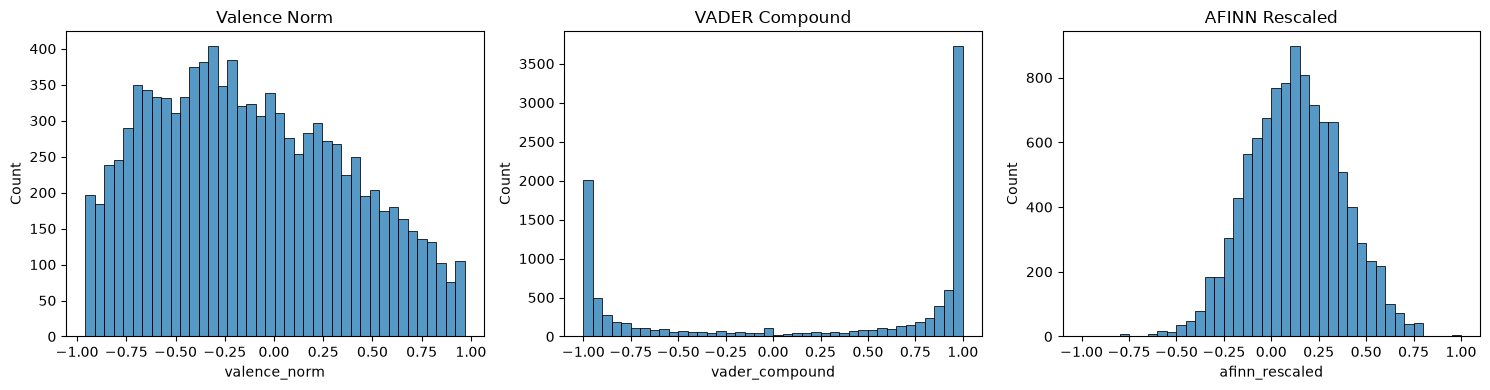

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bins = 40
cols = ['valence_norm', 'vader_compound', 'afinn_rescaled']
plot_titles = [
    'Valence Norm',
    'VADER Compound',
    'AFINN Rescaled'
]

for i, col in enumerate(cols):
    sns.histplot(sample_songs[col], ax=axes[i], bins=bins)
    axes[i].set_title(plot_titles[i])

plt.tight_layout()
plt.show()

In [38]:
# computing alignment with normalized valence and VADER score
sample_songs['audio_vader_alignment'] = (sample_songs['vader_compound'] - sample_songs['valence_norm']) / 2
sample_songs[['valence_norm', 'vader_compound', 'audio_vader_alignment']].describe()

# computing alignment with normalized valence and AFINN score
sample_songs['audio_afinn_alignment'] = (sample_songs['afinn_rescaled'] - sample_songs['valence_norm']) / 2
sample_songs[['valence_norm', 'afinn_rescaled', 'audio_afinn_alignment']].describe()

,valence_norm,afinn_rescaled,audio_afinn_alignment
count,10378.000000,10378.000000,10378.000000
mean,-0.117162,0.127201,0.122181
std,0.483294,0.244955,0.254308
min,-0.959000,-1.000000,-0.744889
25%,-0.512000,-0.042735,-0.058984
50%,-0.166000,0.120370,0.138265
75%,0.252000,0.298246,0.310880
max,0.968000,1.000000,0.909500


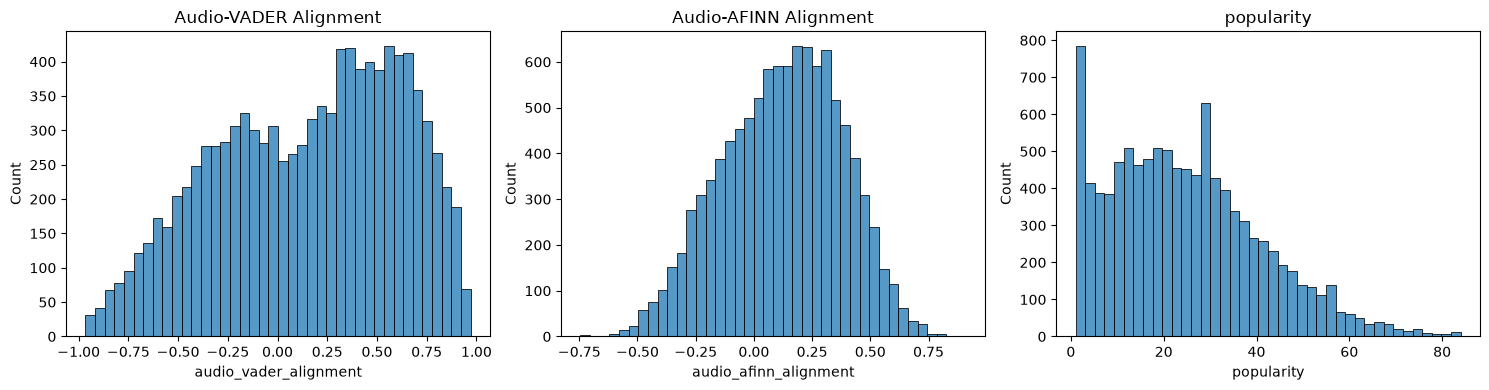

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bins = 40
cols = ['audio_vader_alignment', 'audio_afinn_alignment', 'popularity']
plot_titles = [
    'Audio-VADER Alignment',
    'Audio-AFINN Alignment',
    'popularity'
]

for i, col in enumerate(cols):
    sns.histplot(sample_songs[col], ax=axes[i], bins=bins)
    axes[i].set_title(plot_titles[i])

plt.tight_layout()
plt.show()

In [40]:
sample_songs.to_csv('test/samples_1.csv', index=False)

## Sentiment Analysis on all Songs

In [6]:
# songs separated by year

years_list = [year for year in range(2023, 1999, -1)]
songs_by_year = {}

for year in years_list:
    print(year, end=" ")
    songs_by_year[year] = songs[songs['year'] == year].reset_index(drop=True)

2023 2022 2021 2020 2019 2018 2017 2016 2015 2014 2013 2012 2011 2010 2009 2008 2007 2006 2005 2004 2003 2002 2001 2000 

In [144]:
test_year = 2020
len(songs_by_year[test_year]) == len(pd.read_csv(f'data_filtered/songs_{test_year}.csv'))

True

In [116]:
def get_vader_score(song):
    compound = vader.polarity_scores(song['lyrics'])['compound']
    print(f"\r({song.name})", end="", flush=True)
    return compound

for year in songs_by_year.keys():
    print(year)
    songs_by_year[year]['lyric_sentiment'] = songs_by_year[year].apply(get_vader_score, axis = 1)
    print()

2023
(3421)
2022
(10885)
2021
(10323)
2020
(14663)
2019
(15595)
2018
(15462)
2017
(14587)
2016
(11856)
2015
(12240)
2014
(12120)
2013
(11870)
2012
(11631)
2011
(10458)
2010
(10198)
2009
(10355)
2008
(10077)
2007
(10566)
2006
(10579)
2005
(10064)
2004
(9220)
2003
(8968)
2002
(8375)
2001
(8103)
2000
(7818)


In [ ]:
for year in songs_by_year.keys():
    print(year)
    songs_by_year[year]['alignment_gap'] = songs_by_year[year]['lyric_sentiment'] - songs_by_year[year]['valence_norm']

In [142]:
songs_by_year[test_year][['valence_norm', 'lyric_sentiment', 'alignment_gap', 'popularity']].describe()

,valence_norm,lyric_sentiment,alignment_gap,popularity
count,15463.000000,15463.000000,15463.000000,15463.000000
mean,-0.166101,0.216249,0.382350,28.239734
std,0.460827,0.866037,0.933432,15.884507
min,-0.963800,-1.000000,-1.941900,1.000000
25%,-0.544000,-0.895400,-0.377650,17.000000
50%,-0.216000,0.811500,0.546100,27.000000
75%,0.164000,0.985400,1.173800,38.000000
max,0.968000,1.000000,1.938000,90.000000


In [145]:
display(songs_by_year[test_year].head(3))
display(pd.read_csv(f'data_filtered/songs_{test_year}.csv').head(3))

,index,id,name,album_name,artists,danceability,energy,key,loudness,mode,...,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres,is_valid_lyrics,valence_norm,lyric_sentiment,alignment_gap
0,51,3Q4gttWQ6hxqWOa3tHoTNi,Not You Too (feat. Chris Brown),Dark Lane Demo Tapes,"[""Drake"", ""Chris Brown""]",0.458,0.452,9,-9.299,0,...,Hip-Hop,86,134070748,94.0,"[""3TVXtAsR1Inumwj472S9r4"", ""7bXgB6jMjp9ATFy66e...","[""r&b"", ""rap""]",True,-0.368,0.9971,1.3651
1,56,5hM5arv9KDbCHS0k9uqwjr,Borderline,The Slow Rush,"[""Tame Impala""]",0.621,0.873,5,-3.067,0,...,Rock,86,9857195,86.0,"[""5INjqkS1o8h1imAzPqGZBb""]","[""indie"", ""neo-psychedelic""]",True,0.746,0.9939,0.2479
2,62,7fEoXCZTZFosUFvFQg1BmW,Took Her To The O,Levon James,"[""King Von""]",0.820,0.592,1,-7.002,1,...,Hip-Hop,85,8280096,79.0,"[""6QtgPSJPSzcnn7dPZ4VINp""]","[""chicago drill"", ""drill""]",True,-0.200,-0.9991,-0.7991


,index,id,name,album_name,artists,danceability,energy,key,loudness,mode,...,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres,is_valid_lyrics
0,51,3Q4gttWQ6hxqWOa3tHoTNi,Not You Too (feat. Chris Brown),Dark Lane Demo Tapes,"[""Drake"", ""Chris Brown""]",0.458,0.452,9,-9.299,0,...,269680,first time in a long time hurtin' deeply insid...,2020,Hip-Hop,86,134070748,94.0,"[""3TVXtAsR1Inumwj472S9r4"", ""7bXgB6jMjp9ATFy66e...","[""r&b"", ""rap""]",True
1,56,5hM5arv9KDbCHS0k9uqwjr,Borderline,The Slow Rush,"[""Tame Impala""]",0.621,0.873,5,-3.067,0,...,237800,gone a little far gone a little far this time ...,2020,Rock,86,9857195,86.0,"[""5INjqkS1o8h1imAzPqGZBb""]","[""indie"", ""neo-psychedelic""]",True
2,62,7fEoXCZTZFosUFvFQg1BmW,Took Her To The O,Levon James,"[""King Von""]",0.820,0.592,1,-7.002,1,...,196180,"bang von, von huh, what? von, von dj on the be...",2020,Hip-Hop,85,8280096,79.0,"[""6QtgPSJPSzcnn7dPZ4VINp""]","[""chicago drill"", ""drill""]",True


In [7]:
songs_new = pd.DataFrame()

for sy in songs_by_year.values():
    songs_new = pd.concat([sy, songs_new])

print(len(songs_new) == len(songs))
display(songs_new.head(3))
display(songs.head(3))

True


,Unnamed: 0,index,id,name,album_name,artists,danceability,energy,key,loudness,...,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres,is_valid_lyrics,valence_norm,lyric_sentiment,alignment_gap
0,0,7,60a0Rd6pjrkxjPbaKzXjfq,In the End,Hybrid Theory (Bonus Edition),"[""Linkin Park""]",0.556,0.864,3,-5.870,...,Rock,90,32504225,90.0,"[""6XyY86QOPPrYVGvF9ch6wz""]","[""alternative metal"", ""nu metal"", ""rap metal"",...",True,-0.200,-0.9200,-0.7200
1,1,113,0I3q5fE6wg7LIfHGngUTnV,Ms. Jackson,Stankonia,"[""Outkast""]",0.843,0.806,4,-5.946,...,Hip-Hop,84,3488861,76.0,"[""1G9G7WwrXka3Z1r7aIDjI7""]","[""hip hop"", ""southern hip hop""]",True,0.226,-0.9618,-1.1878
2,2,116,3K4HG9evC7dg3N0R9cYqk4,One Step Closer,Hybrid Theory (Bonus Edition),"[""Linkin Park""]",0.492,0.969,9,-4.419,...,Rock,84,32504225,90.0,"[""6XyY86QOPPrYVGvF9ch6wz""]","[""alternative metal"", ""nu metal"", ""rap metal"",...",True,0.076,-0.2767,-0.3527


,Unnamed: 0,index,id,name,album_name,artists,danceability,energy,key,loudness,...,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres,is_valid_lyrics,valence_norm,lyric_sentiment,alignment_gap
0,0,256,3iBgrkexCzVuPy4O9vx7Mf,Glue Song,Glue Song,"[""beabadoobee""]",0.620,0.409,1,-10.146,...,Pop,81,6764580,80.000000,"[""35l9BRT7MXmM8bv2WDQiyB""]","[""bedroom pop""]",True,0.164,-0.1372,-0.3012
1,1,646,60SvhHtwefT0e2G7i7kOH3,New Gold (feat. Tame Impala and Bootie Brown),Cracker Island,"[""Gorillaz"", ""Tame Impala"", ""Bootie Brown""]",0.695,0.923,1,-3.930,...,Rock,77,24787609,78.333333,"[""3AA28KZvwAUcZuOKwyblJQ"", ""5INjqkS1o8h1imAzPq...","[""indie"", ""neo-psychedelic""]",True,0.102,0.5043,0.4023
2,2,891,0FA4wrjDJvJTTU8AepZTup,Watch This - ARIZONATEARS Pluggnb Remix,Watch This (ARIZONATEARS Pluggnb Remix),"[""Lil Uzi Vert"", ""sped up nightcore"", ""ARIZONA...",0.686,0.897,11,-7.180,...,Hip-Hop,75,19685914,71.333333,"[""4O15NlyKLIASxsJ0PrXPfz"", ""0M2CO5ijP35MDhNwvp...","[""melodic rap"", ""nightcore""]",True,-0.290,-0.9986,-0.7086


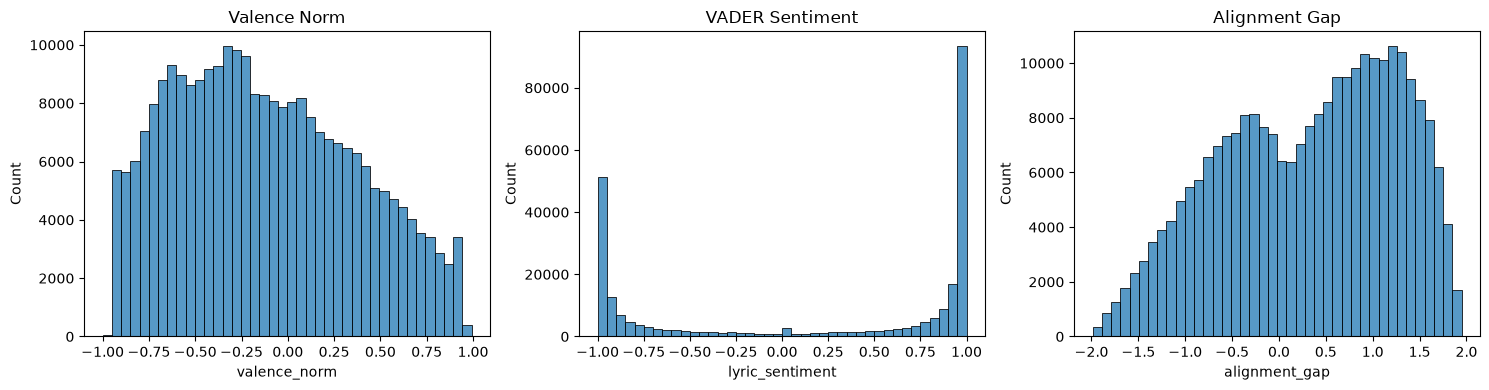

In [154]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bins = 40
cols = ['valence_norm', 'lyric_sentiment', 'alignment_gap']
plot_titles = [
    'Valence Norm',
    'VADER Sentiment',
    'Alignment Gap'
]

for i, col in enumerate(cols):
    sns.histplot(songs_new[col], ax=axes[i], bins=bins)
    axes[i].set_title(plot_titles[i])

plt.tight_layout()
plt.show()

In [8]:
# save new data

x = input('Save sentiment and alignment scores? ')

if x == 'y' or x == 'yes':
    print('Saving data...')
    for year, sy in songs_by_year.items():
        print(year)
        sy.to_csv(f'data_filtered/songs_{year}.csv')
else:
    print('No save')

Saving data...
2023
2022
2021
2020
2019
2018
2017
2016
2015
2014
2013
2012
2011
2010
2009
2008
2007
2006
2005
2004
2003
2002
2001
2000
